**AB Test project**

In [2]:
import kagglehub

# Download latest version
download_path = kagglehub.dataset_download("adarsh0806/ab-testing-practice")

print("Path to dataset files:", download_path)

c:\Users\User\Documents\PythonScripts\ABtest_project\abtest\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\adarsh0806\ab-testing-practice\versions\1


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from pathlib import Path

**User ID** - id пользователя

**Group** - к какой группе принадлежит пользователь

**Page views** - количество просмотренных пользователем страниц за сессию

**Time Spent** - время сессии (в секундах)

**Conversion** - конверсия:)

**Device** - устройство, с которого произошел вход

**Location** - страна, из которой был произведен вход

In [38]:
file_path = Path(download_path)/"ab_testing.csv"
ab_test = pd.read_csv(file_path)
print('Dataset size:', ab_test.shape)
display(ab_test.head(5))
display(ab_test.isna().any())

Dataset size: (5000, 7)


,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


User ID       False
Group         False
Page Views    False
Time Spent    False
Conversion    False
Device        False
Location      False
dtype: bool

In [33]:
print('\n', ab_test.groupby(by = ['Group', 'Device']).size(), '\n')


 Group  Device 
A      Desktop    1244
       Mobile     1275
B      Desktop    1294
       Mobile     1187
dtype: int64 



**Гипотезы**:

1. Увеличение среднего количества просмотренных пользователем страниц за сессию (увеличение вовлеченности пользователя)

2. Увеличение среднего времени сессии (нужно учесть возможность изменения пропорции числа пользователей с телефона и ПК)

3. Увеличение положительной конверсии


**Проверка гипотез**:

1. t-критерий Стьюдента

2. t-критерий Стьюдента

3. Критерий $\chi^2$ Пирсона

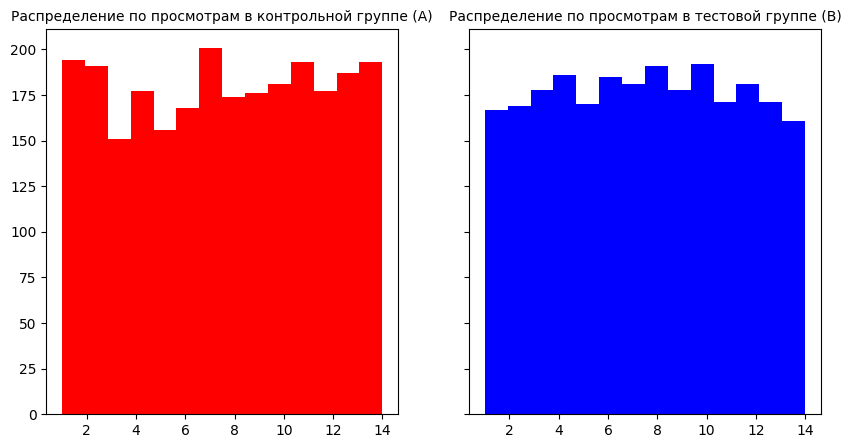

In [40]:
# Проверка первой гипотезы

# Разделяем просмотры по группам
a_group_avg_views = ab_test.loc[ab_test['Group'] == 'A']['Page Views']
b_group_avg_views = ab_test.loc[ab_test['Group'] == 'B']['Page Views']

# Смотрим на распределения
fig, ax = plt.subplots(nrows = 1, ncols = 2, sharey = True, figsize = (10, 5))
ax[0].hist(a_group_avg_views, bins = 14, color = 'red')
ax[0].set_title('Распределение по просмотрам в контрольной группе (A)', fontsize = 10)
ax[1].hist(b_group_avg_views, bins = 14, color = 'blue')
ax[1].set_title('Распределение по просмотрам в тестовой группе (B)', fontsize = 10)
plt.show()

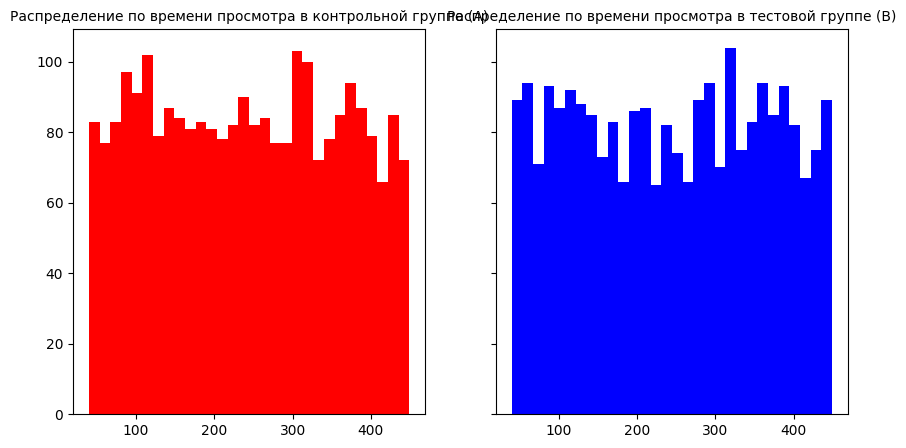

In [45]:
# Проверка второй гипотезы

# Распределяем время сессии по группам
a_group_avg_time = ab_test.loc[ab_test['Group'] == 'A']['Time Spent']
b_group_avg_time = ab_test.loc[ab_test['Group'] == 'B']['Time Spent']

# Строим распределение
fig, ax = plt.subplots(nrows = 1, ncols = 2, sharey = True, figsize = (10, 5))
ax[0].hist(a_group_avg_time, bins = 30, color = 'red')
ax[0].set_title('Распределение по времени просмотра в контрольной группе (A)', fontsize = 10)
ax[1].hist(b_group_avg_time, bins = 30, color = 'blue')
ax[1].set_title('Распределение по времени просмотра в тестовой группе (B)', fontsize = 10)
plt.show()